# Figures for padat karya

This python notebook creates graphs in the paper. Maintained by Krisna Gupta and Rayhan Hatta.

## GDP growth

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

excel_path = "PDB.xlsx"
fig_path   = "gdp_growth.png"

colors    = ["#f0a22e", "#a5644e", "#c00000", "#a19574"]
df        = pd.read_excel(excel_path)
year_col  = df.columns[0]
y_columns = ['growth_kpk', 'growth_tpt', 'growth_non_migas', 'growth_nasional']
labels    = ['Leather and Footwear Industry', 'Textile and Garment Industry', 'Non-oil and Gas Industry', 'National']

fig, ax = plt.subplots(figsize=(9, 6))

for i, col in enumerate(y_columns):
    ax.plot(df[year_col], df[col], color=colors[i], linewidth=2.5,
            label=labels[i], marker='o', markersize=4)

last_year = df[year_col].iloc[-1]

# ── Smart label spreading ─────────────────────────────────────────
min_gap = 0.9  # minimum vertical gap between labels (tweak if needed)

# Sort labels by actual y value (bottom to top)
label_info = sorted(
    [(col, df[col].iloc[-1], i) for i, col in enumerate(y_columns)],
    key=lambda x: x[1]
)

# Spread any labels that are too close together
adj_y = [item[1] for item in label_info]
for i in range(1, len(adj_y)):
    if adj_y[i] - adj_y[i-1] < min_gap:
        mid        = (adj_y[i] + adj_y[i-1]) / 2
        adj_y[i]   = mid + min_gap / 2
        adj_y[i-1] = mid - min_gap / 2

# Draw each label with a thin connector to the actual line endpoint
for j, (col, actual_y, color_idx) in enumerate(label_info):
    label_y = adj_y[j]
    needs_connector = abs(label_y - actual_y) > 0.05

    ax.annotate(
        f'{actual_y:.1f}%',
        xy=(last_year, actual_y),
        xytext=(last_year + 0.3, label_y),
        fontsize=10,
        color=colors[color_idx],
        fontweight='bold',
        verticalalignment='center',
        arrowprops=dict(
            arrowstyle='-',
            color=colors[color_idx],
            lw=0.8
        ) if needs_connector else None
    )
# ─────────────────────────────────────────────────────────────────

ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Growth (%)', fontsize=12)
ax.set_xlim(df[year_col].min(), df[year_col].max() + 1.5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=4, frameon=False)
ax.grid(True, alpha=0.3)
ax.set_xticks(df[year_col])
plt.tight_layout()

plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {fig_path}")
plt.show()

### Quarterly version (BPS API)

Same chart on quarterly year-on-year growth pulled live from the BPS WebAPI (dynamic table 104). Needs the `BPS_API_KEY` environment variable. The pulled data are also saved to `pdb_growth_quarterly_bps.csv` as a snapshot. The chart starts at 2012Q1 (y-on-y growth is available from 2011Q1).

Data: 58 quarters, 2012Q1 to 2026Q2


Figure saved to: gdp_growth_quarterly.png


Figure saved to: gdp_growth_quarterly_id.png


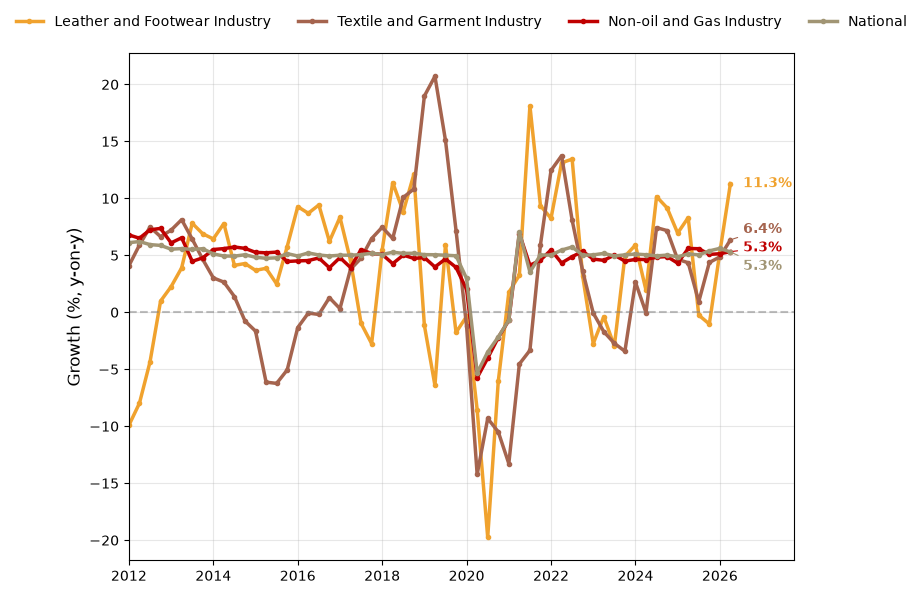

In [1]:
"""Quarterly (y-on-y) version of gdp_growth.png, built from the BPS WebAPI.

Data: BPS dynamic table var 104 "[Seri 2010] Laju Pertumbuhan PDB Seri 2010", domain 0000,
y-on-y quarterly growth (turvar 5, turtahun 31-34). Requires env var BPS_API_KEY.
"""
import os
import re

import matplotlib.pyplot as plt
from source_note import save_with_source
import pandas as pd
import requests

BASE = "https://webapi.bps.go.id/v1/api"
KEY = os.environ["BPS_API_KEY"]
VAR = 104
TURVAR_YOY = "5"
QUARTERS = {"31": 1, "32": 2, "33": 3, "34": 4}
ITEMS = {
    "growth_kpk": "4. Industri Kulit, Barang dari Kulit dan Alas Kaki",
    "growth_tpt": "3. Industri Tekstil dan Pakaian Jadi",
    "growth_non_migas": "Industri Pengolahan Non Migas",
    "growth_nasional": "C.  PRODUK DOMESTIK BRUTO",
}

data_path = "pdb_growth_quarterly_bps.csv"
fig_path = "gdp_growth_quarterly.png"


def list_years():
    ths = []
    for page in (1, 2, 3):
        r = requests.get(f"{BASE}/list/model/th/domain/0000/var/{VAR}/page/{page}/key/{KEY}", timeout=90).json()
        d = r.get("data")
        if not d or len(d) < 2 or not d[1]:
            break
        ths += d[1]
    return {str(t["th_id"]): int(t["th"]) for t in ths if int(t["th"]) >= 2010}


def fetch_year(th_id, year):
    r = requests.get(f"{BASE}/list/model/data/domain/0000/var/{VAR}/th/{th_id}/key/{KEY}", timeout=120).json()
    if r.get("status") != "OK":
        return []
    labels = {str(v["val"]): re.sub("<.*?>", "", v["label"]).strip() for v in r["vervar"]}
    wanted = {v: k for k, v in ITEMS.items()}
    rows = []
    for key, value in r["datacontent"].items():
        for tt, q in QUARTERS.items():
            suffix = f"{VAR}{TURVAR_YOY}{th_id}{tt}"
            if key.endswith(suffix) and labels.get(key[: -len(suffix)]) in wanted:
                rows.append({"year": year, "quarter": q, "series": wanted[labels[key[: -len(suffix)]]], "growth": value})
    return rows


rows = []
for th_id, year in sorted(list_years().items(), key=lambda x: x[1]):
    rows += fetch_year(th_id, year)

df = pd.DataFrame(rows).pivot_table(index=["year", "quarter"], columns="series", values="growth").reset_index()
df = df.sort_values(["year", "quarter"]).reset_index(drop=True)
df["t"] = df["year"] + (df["quarter"] - 1) / 4          # decimal year for the x-axis
df = df[df["t"] >= 2012].reset_index(drop=True)          # chart starts at 2012Q1
df.to_csv(data_path, index=False)
print(f"Data: {len(df)} quarters, {df['year'].iloc[0]}Q{df['quarter'].iloc[0]} to {df['year'].iloc[-1]}Q{df['quarter'].iloc[-1]}")

colors    = ["#f0a22e", "#a5644e", "#c00000", "#a19574"]
y_columns = ['growth_kpk', 'growth_tpt', 'growth_non_migas', 'growth_nasional']
labels    = ['Leather and Footwear Industry', 'Textile and Garment Industry', 'Non-oil and Gas Industry', 'National']

fig, ax = plt.subplots(figsize=(9, 6))

for i, col in enumerate(y_columns):
    ax.plot(df["t"], df[col], color=colors[i], linewidth=2.5,
            label=labels[i], marker='o', markersize=3)

last_t = df["t"].iloc[-1]

# ── Smart label spreading ─────────────────────────────────────────
y_all   = df[y_columns].stack()
min_gap = 0.04 * (y_all.max() - y_all.min())  # label gap scaled to the y-range (quarterly swings are wider than annual)

label_info = sorted(
    [(col, df[col].iloc[-1], i) for i, col in enumerate(y_columns)],
    key=lambda x: x[1]
)

adj_y = [item[1] for item in label_info]
for _ in range(10):  # repeat until no pair is closer than min_gap
    for i in range(1, len(adj_y)):
        if adj_y[i] - adj_y[i-1] < min_gap:
            mid        = (adj_y[i] + adj_y[i-1]) / 2
            adj_y[i]   = mid + min_gap / 2
            adj_y[i-1] = mid - min_gap / 2

for j, (col, actual_y, color_idx) in enumerate(label_info):
    label_y = adj_y[j]
    needs_connector = abs(label_y - actual_y) > 0.05

    ax.annotate(
        f'{actual_y:.1f}%',
        xy=(last_t, actual_y),
        xytext=(last_t + 0.3, label_y),
        fontsize=10,
        color=colors[color_idx],
        fontweight='bold',
        verticalalignment='center',
        arrowprops=dict(
            arrowstyle='-',
            color=colors[color_idx],
            lw=0.8
        ) if needs_connector else None
    )
# ─────────────────────────────────────────────────────────────────

ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Growth (%, y-on-y)', fontsize=12)
ax.set_xlim(df["t"].min(), last_t + 1.5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=4, frameon=False)
ax.grid(True, alpha=0.3)
ax.set_xticks(sorted(range(int(df["year"].max()), int(df["year"].min()) - 1, -2)))  # every 2nd year, anchored on the last year
plt.tight_layout()

save_with_source(fig, fig_path, "BPS.")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter
import numpy as np

excel_path = "PDB.xlsx"
fig_path   = "gdp_covid_disruption.png"

colors = ["#f0a22e", "#a5644e"]
df = pd.read_excel(excel_path)

year_col = df.columns[0]  # auto-detects your year column

# Legend
AA = 'Actual GDP'
BB = 'Trend Pre-COVID + Counterfactual'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Plot 1: TPT ──────────────────────────────────────────────────
pre_covid_mask     = df[year_col] < 2020
pre_covid_data_tpt = df[pre_covid_mask]['TPT'].dropna()
pre_covid_years    = df[pre_covid_mask][year_col]

if len(pre_covid_data_tpt) > 3:
    cycle_pre_tpt, trend_pre_tpt = hpfilter(pre_covid_data_tpt, lamb=1600)

    last_few_trend_tpt = trend_pre_tpt[-3:]
    last_few_years     = pre_covid_years.iloc[-3:].values
    slope_tpt = (last_few_trend_tpt.iloc[-1] - last_few_trend_tpt.iloc[0]) / (last_few_years[-1] - last_few_years[0])

    extended_years    = np.arange(2020, 2026)
    extended_trend_tpt = [
        trend_pre_tpt.iloc[-1] + slope_tpt * (year - pre_covid_years.iloc[-1])
        for year in extended_years
    ]

ax1.plot(df[year_col], df['TPT'], color=colors[0], linewidth=2.5,
         label=AA, marker='o', markersize=4)

combined_years    = list(pre_covid_years) + list(extended_years)
combined_trend_tpt = list(trend_pre_tpt) + extended_trend_tpt
ax1.plot(combined_years, combined_trend_tpt, color=colors[1], linewidth=2,
         linestyle='--', alpha=0.8, label=BB)

ax1.axvline(x=2020, color='red', linestyle='-', alpha=0.5, linewidth=1)
ax1.set_xlabel('', fontsize=11)
ax1.set_ylabel('GDP (Billion Rupiah)', fontsize=11)
ax1.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=2, frameon=False, fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(range(2010, 2025, 2)))
ax1.text(0.02, 0.98, 'Textile and Garment Industry', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', verticalalignment='top')

# ── Plot 2: KPK ──────────────────────────────────────────────────
pre_covid_data = df[pre_covid_mask]['KPK'].dropna()

if len(pre_covid_data) > 3:
    cycle_pre, trend_pre = hpfilter(pre_covid_data, lamb=1600)

    last_few_trend = trend_pre[-3:]
    slope = (last_few_trend.iloc[-1] - last_few_trend.iloc[0]) / (last_few_years[-1] - last_few_years[0])

    extended_trend = [
        trend_pre.iloc[-1] + slope * (year - pre_covid_years.iloc[-1])
        for year in extended_years
    ]

ax2.plot(df[year_col], df['KPK'], color=colors[0], linewidth=2.5,
         label=AA, marker='o', markersize=4)

combined_trend = list(trend_pre) + extended_trend
ax2.plot(combined_years, combined_trend, color=colors[1], linewidth=2,
         linestyle='--', alpha=0.8, label=BB)

ax2.axvline(x=2020, color='red', linestyle='-', alpha=0.5, linewidth=1)
ax2.set_xlabel('', fontsize=11)
ax2.set_ylabel('GDP (Billion Rupiah)', fontsize=11)
ax2.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=2, frameon=False, fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(range(2010, 2025, 2)))
ax2.text(0.02, 0.98, 'Leather and Footwear Industry', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', verticalalignment='top')

plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {fig_path}")
plt.show()

### Quarterly version (BPS API)

Same chart on quarterly constant-2010 GDP pulled live from the BPS WebAPI (dynamic table 65). Needs the `BPS_API_KEY` environment variable. The pulled data are also saved to `pdb_quarterly_bps.csv` as a snapshot. The counterfactual slope is the straight line from the first to the last point of the pre-COVID HP trend (2010Q1 to 2019Q4), i.e. average growth over the whole pre-COVID decade.

Data: 66 quarters, 2010Q1 to 2026Q2


Figure saved to: gdp_covid_disruption_quarterly.png


Figure saved to: gdp_covid_disruption_quarterly_id.png


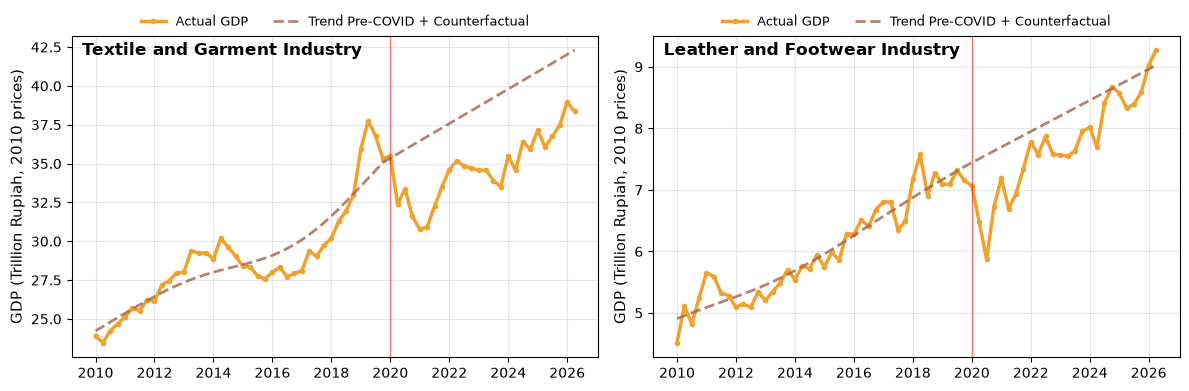

In [2]:
"""Quarterly version of fig/gdp_covid_disruption.png, built from the BPS WebAPI.

Data: BPS dynamic table var 65 "[Seri 2010] PDB Seri 2010", domain 0000,
constant 2010 prices (turvar 237), quarterly (turtahun 31-34), 2010Q1 onward.
Requires env var BPS_API_KEY.
"""
import os
import re

import matplotlib.pyplot as plt
from source_note import save_with_source
import numpy as np
import pandas as pd
import requests
from statsmodels.tsa.filters.hp_filter import hpfilter

BASE = "https://webapi.bps.go.id/v1/api"
KEY = os.environ["BPS_API_KEY"]
VAR = 65
TURVAR_CONST = "237"
QUARTERS = {"31": 1, "32": 2, "33": 3, "34": 4}
ITEMS = {
    "TPT": "3. Industri Tekstil dan Pakaian Jadi",
    "KPK": "4. Industri Kulit, Barang dari Kulit dan Alas Kaki",
}

data_path = "pdb_quarterly_bps.csv"
fig_path = "gdp_covid_disruption_quarterly.png"


def list_years():
    ths = []
    for page in (1, 2, 3):
        r = requests.get(f"{BASE}/list/model/th/domain/0000/var/{VAR}/page/{page}/key/{KEY}", timeout=90).json()
        d = r.get("data")
        if not d or len(d) < 2 or not d[1]:
            break
        ths += d[1]
    return {str(t["th_id"]): int(t["th"]) for t in ths if int(t["th"]) >= 2010}


def fetch_year(th_id, year):
    r = requests.get(f"{BASE}/list/model/data/domain/0000/var/{VAR}/th/{th_id}/key/{KEY}", timeout=120).json()
    if r.get("status") != "OK":
        return []
    labels = {str(v["val"]): re.sub("<.*?>", "", v["label"]).strip() for v in r["vervar"]}
    rows = []
    for key, value in r["datacontent"].items():
        for tt, q in QUARTERS.items():
            suffix = f"{VAR}{TURVAR_CONST}{th_id}{tt}"
            if key.endswith(suffix) and labels.get(key[: -len(suffix)]) in ITEMS.values():
                rows.append({"year": year, "quarter": q, "item": labels[key[: -len(suffix)]], "value_bn": value})
    return rows


rows = []
for th_id, year in sorted(list_years().items(), key=lambda x: x[1]):
    rows += fetch_year(th_id, year)

long = pd.DataFrame(rows)
long["series"] = long["item"].map({v: k for k, v in ITEMS.items()})
df = long.pivot_table(index=["year", "quarter"], columns="series", values="value_bn").reset_index()
df = df.sort_values(["year", "quarter"]).reset_index(drop=True)
df["t"] = df["year"] + (df["quarter"] - 1) / 4          # decimal year for the x-axis
df[["TPT", "KPK"]] = df[["TPT", "KPK"]] / 1000           # billion -> trillion rupiah
df.to_csv(data_path, index=False)
print(f"Data: {len(df)} quarters, {df['year'].min()}Q{df['quarter'].iloc[0]} to {df['year'].max()}Q{df['quarter'].iloc[-1]}")

colors = ["#f0a22e", "#a5644e"]
AA = "Actual GDP"
BB = "Trend Pre-COVID + Counterfactual"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

pre_covid_mask = df["t"] < 2020
pre_covid_t = df.loc[pre_covid_mask, "t"]
extended_t = df.loc[~pre_covid_mask, "t"]
combined_t = list(pre_covid_t) + list(extended_t)
TREND_WINDOW = int(pre_covid_mask.sum())   # all pre-COVID quarters: slope from first to last HP trend point


def trend_with_counterfactual(series):
    pre = df.loc[pre_covid_mask, series].dropna()
    _, trend_pre = hpfilter(pre, lamb=1600)
    last_trend = trend_pre[-TREND_WINDOW:]
    last_t = pre_covid_t.iloc[-TREND_WINDOW:].values
    slope = (last_trend.iloc[-1] - last_trend.iloc[0]) / (last_t[-1] - last_t[0])
    extended = [trend_pre.iloc[-1] + slope * (t - pre_covid_t.iloc[-1]) for t in extended_t]
    return list(trend_pre) + extended


for ax, series, title in ((ax1, "TPT", "Textile and Garment Industry"),
                          (ax2, "KPK", "Leather and Footwear Industry")):
    ax.plot(df["t"], df[series], color=colors[0], linewidth=2.5, label=AA, marker="o", markersize=3)
    ax.plot(combined_t, trend_with_counterfactual(series), color=colors[1], linewidth=2,
            linestyle="--", alpha=0.8, label=BB)
    ax.axvline(x=2020, color="red", linestyle="-", alpha=0.5, linewidth=1)
    ax.set_xlabel("", fontsize=11)
    ax.set_ylabel("GDP (Trillion Rupiah, 2010 prices)", fontsize=11)
    ax.legend(bbox_to_anchor=(0.5, 1.1), loc="upper center", ncol=2, frameon=False, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(range(2010, 2027, 2)))
    ax.text(0.02, 0.98, title, transform=ax.transAxes, fontsize=12, fontweight="bold", verticalalignment="top")

plt.tight_layout()
save_with_source(fig, fig_path, "BPS.")


### Global Import

Figure saved to: investment_comparison.png


Figure saved to: investment_comparison_id.png


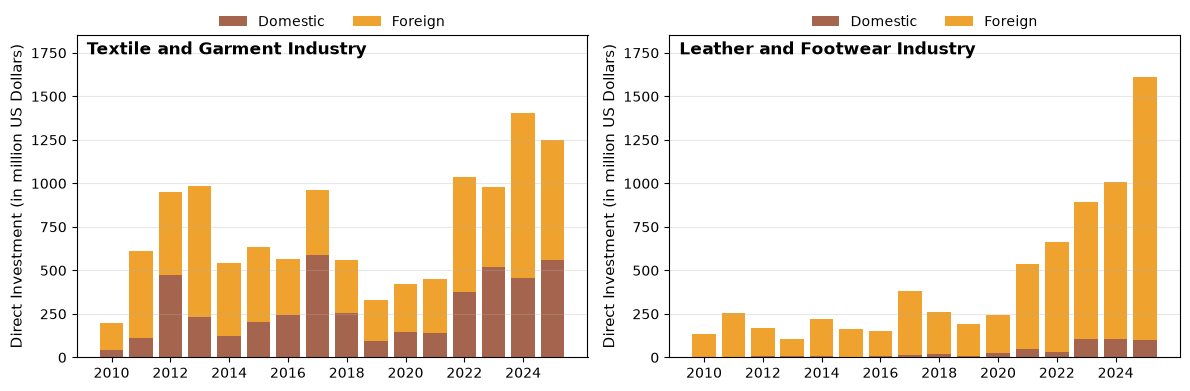

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from source_note import save_with_source

excel_path = "Base Investment.xlsx"
fig_path   = "investment_comparison.png"

colors = ["#f0a22e", "#a5644e"]
df = pd.read_excel(excel_path, sheet_name="Chart Data")

year_col    = 'year'
tpt_fdi_col = 'tpt_asing_usd_mn'
tpt_ddi_col = 'tpt_domestik_usd_mn'
kpk_fdi_col = 'kpk_asing_usd_mn'
kpk_ddi_col = 'kpk_domestik_usd_mn'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

def plot_stacked(ax, years, ddi, fdi, title):
    ax.bar(years, ddi, color=colors[1], label='Domestic')
    ax.bar(years, fdi, bottom=ddi,      color=colors[0], label='Foreign')

    ax.set_ylabel('Direct Investment (in million US Dollars)', fontsize=11)
    ax.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=2, frameon=False)
    ax.grid(True, alpha=0.3, axis='y')
    ax.text(0.02, 0.98, title, transform=ax.transAxes,
            fontsize=12, fontweight='bold', verticalalignment='top')
    ax.set_xticks(list(range(2010, 2025, 2)))

plot_stacked(ax1, df[year_col], df[tpt_ddi_col], df[tpt_fdi_col], 'Textile and Garment Industry')
plot_stacked(ax2, df[year_col], df[kpk_ddi_col], df[kpk_fdi_col], 'Leather and Footwear Industry')

max_val = max((df[tpt_ddi_col] + df[tpt_fdi_col]).max(),
              (df[kpk_ddi_col] + df[kpk_fdi_col]).max())
ax1.set_ylim(0, max_val * 1.15)
ax2.set_ylim(0, max_val * 1.15)

plt.tight_layout()
save_with_source(fig, fig_path, "BPS, accessed through CEIC.", "BPS, diakses melalui CEIC.")
plt.show()

Figure saved to: workers.png


Figure saved to: workers_id.png


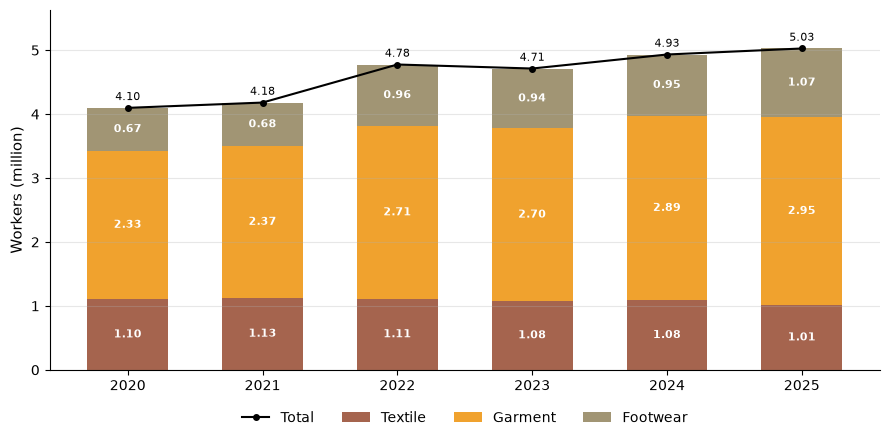

In [4]:
import matplotlib.pyplot as plt
from source_note import save_with_source
import numpy as np

# Number of workers in the textile, garment and footwear industries (BPS, Sakernas).
# Values taken from the original DEN chart (fig/workers_original.png); no source
# spreadsheet is redistributed here.
fig_path = "workers.png"
years    = [2020, 2021, 2022, 2023, 2024, 2025]
workers  = {
    "Textile":  [1_104_706, 1_127_034, 1_109_433, 1_076_863, 1_084_815, 1_011_142],
    "Garment":  [2_325_021, 2_372_014, 2_705_834, 2_699_151, 2_892_840, 2_945_500],
    "Footwear": [  667_962,   681_463,   960_607,   937_011,   954_637, 1_069_759],
}
colors = {"Textile": "#a5644e", "Garment": "#f0a22e", "Footwear": "#a19574"}

fig, ax = plt.subplots(figsize=(9, 4.5))
bottom = np.zeros(len(years))
for name, vals in workers.items():
    v = np.array(vals) / 1e6
    ax.bar(years, v, bottom=bottom, color=colors[name], label=name, width=0.6)
    for x, b, h in zip(years, bottom, v):
        ax.text(x, b + h / 2, f"{h:.2f}", ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")
    bottom += v

ax.plot(years, bottom, color="black", marker="o", markersize=4, linewidth=1.5, label="Total")
for x, t in zip(years, bottom):
    ax.text(x, t + 0.08, f"{t:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Workers (million)", fontsize=11)
ax.set_ylim(0, bottom.max() * 1.12)
ax.set_xticks(years)
ax.grid(True, alpha=0.3, axis="y")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)

plt.tight_layout()
save_with_source(fig, fig_path, "BPS, Sakernas.")


## Import US

> **Note:** the next cell requires `../dat/TradeData.xlsx` (bilateral COMTRADE data by reporter/partner), which is **not tracked in this repository**. The resulting market shares are preserved in the cell output below and hard-coded as Table 1 in the paper.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter
import numpy as np
colors = ["#f0a22e","#a5644e"]
df=pd.read_excel('../dat/TradeData.xlsx',sheet_name='fin')

# Filter data for years 2015 and 2024
df_filtered = df[df['period'].isin([2015, 2024])]

# --- USA Import Shares ---
# Filter for USA as reporter
usa_data = df_filtered[df_filtered['reporterISO'] == 'USA']

# Get W00 (World) totals for each year
usa_world_2015 = usa_data[(usa_data['partnerISO'] == 'W00') & (usa_data['period'] == 2015)]['cifvalue'].sum()
usa_world_2024 = usa_data[(usa_data['partnerISO'] == 'W00') & (usa_data['period'] == 2024)]['cifvalue'].sum()

# Sum imports by partner and year (excluding W00)
usa_partners = usa_data[usa_data['partnerISO'] != 'W00']
usa_by_partner = usa_partners.groupby(['partnerISO', 'period'])['cifvalue'].sum().reset_index()

# Pivot to get 2015 and 2024 as columns
usa_pivot = usa_by_partner.pivot(index='partnerISO', columns='period', values='cifvalue').fillna(0)

# Calculate shares using W00 as denominator
usa_shares = pd.DataFrame({
    'Partner': usa_pivot.index,
    'Share_2015': (usa_pivot[2015] / usa_world_2015 * 100).values if usa_world_2015 > 0 else 0,
    'Share_2024': (usa_pivot[2024] / usa_world_2024 * 100).values if usa_world_2024 > 0 else 0
})

# Sort by 2024 share descending
usa_shares = usa_shares.sort_values('Share_2024', ascending=False).reset_index(drop=True)

# --- EUR Import Shares ---
# Filter for EUR as reporter
eur_data = df_filtered[df_filtered['reporterISO'] == 'EUR']

# Get W00 (World) totals for each year
eur_world_2015 = eur_data[(eur_data['partnerISO'] == 'W00') & (eur_data['period'] == 2015)]['cifvalue'].sum()
eur_world_2024 = eur_data[(eur_data['partnerISO'] == 'W00') & (eur_data['period'] == 2024)]['cifvalue'].sum()

# Sum imports by partner and year (excluding W00)
eur_partners = eur_data[eur_data['partnerISO'] != 'W00']
eur_by_partner = eur_partners.groupby(['partnerISO', 'period'])['cifvalue'].sum().reset_index()

# Pivot to get 2015 and 2024 as columns
eur_pivot = eur_by_partner.pivot(index='partnerISO', columns='period', values='cifvalue').fillna(0)

# Calculate shares using W00 as denominator
eur_shares = pd.DataFrame({
    'Partner': eur_pivot.index,
    'Share_2015': (eur_pivot[2015] / eur_world_2015 * 100).values if eur_world_2015 > 0 else 0,
    'Share_2024': (eur_pivot[2024] / eur_world_2024 * 100).values if eur_world_2024 > 0 else 0
})

# Sort by 2024 share descending
eur_shares = eur_shares.sort_values('Share_2024', ascending=False).reset_index(drop=True)

# Display dataframes
print("USA Import Shares by Partner:")
display(usa_shares)
print("\nEUR Import Shares by Partner:")
display(eur_shares)

# Export to Excel
with pd.ExcelWriter('../dat/import_shares_by_partner.xlsx') as writer:
    usa_shares.to_excel(writer, sheet_name='USA', index=False)
    eur_shares.to_excel(writer, sheet_name='EUR', index=False)

print("\nData exported to '../dat/import_shares_by_partner.xlsx'")



USA Import Shares by Partner:


,Partner,Share_2015,Share_2024
0,CHN,44.001678,29.218172
1,VNM,11.801339,19.159276
2,IND,5.144900,6.522472
3,BGD,4.369216,6.027059
4,IDN,5.039303,5.459677
5,MEX,3.838526,3.709627
6,PAK,2.243362,3.006150
7,TUR,0.547937,0.954722



EUR Import Shares by Partner:


,Partner,Share_2015,Share_2024
0,CHN,39.089822,30.696799
1,BGD,13.121242,16.074822
2,TUR,9.727694,9.053681
3,VNM,5.954668,8.636320
4,IND,6.892003,5.365280
5,PAK,3.460056,4.771423
6,IDN,2.662618,2.146570
7,MEX,0.097317,0.096208



Data exported to '../dat/import_shares_by_partner.xlsx'


Figure saved to: fig1.png


Figure saved to: fig1_id.png


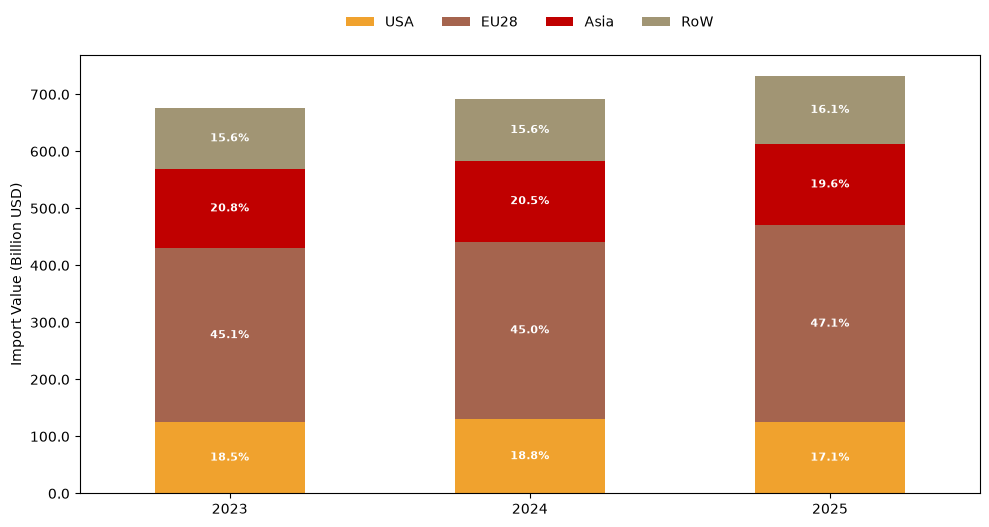

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from source_note import save_with_source
from matplotlib.ticker import FuncFormatter

excel_path = "Base Impor Dunia.xlsx"
fig_path   = "fig1.png"

# --- Step 1: Load dataset ---
df = pd.read_excel(excel_path, sheet_name="fin")

# ensure numeric year columns (coerce non-numeric to NaN)
year_cols = [2023, 2024, 2025]
# df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")

# --- Step 2: Aggregate by Region ---
region_summary = df.groupby("Region")[year_cols].sum()

# --- Step 3: Transpose for plotting ---
region_summary = region_summary.T
region_summary = region_summary[["USA", "EU28", "Asia", "RoW"]]  # enforce order

# --- Step 4: Plot stacked bar chart with custom colors ---
colors = ["#f0a22e", "#a5644e", "#c00000", "#a19574"]
ax = region_summary.plot(kind="bar", stacked=True, figsize=(10, 6), color=colors)

# --- Step 5: Annotate percentage shares ---
for i, year in enumerate(region_summary.index):
    total = region_summary.loc[year].sum()
    cumulative = 0
    for region, value in region_summary.loc[year].items():
        cumulative += value
        pct = value / total * 100
        ax.text(
            i, cumulative - value / 2, f"{pct:.1f}%",
            ha="center", va="center", color="white", fontsize=8, fontweight="bold"
        )

# --- Step 6: Customize chart ---
ax.legend(title=None, bbox_to_anchor=(0.5, 1.12), loc="upper center", ncol=4, frameon=False)
formatter = FuncFormatter(lambda x, pos: f"{x/1e6:.1f}")
ax.yaxis.set_major_formatter(formatter)
plt.xticks(rotation=0)
plt.xlabel("")
plt.ylabel("Import Value (Billion USD)")

# Set x-axis to show years as integers
ax.set_xticklabels([int(x) for x in region_summary.index])

plt.tight_layout(rect=[0, 0, 1, 0.9])
save_with_source(ax.figure, fig_path, "UN Comtrade.")
plt.show()

> **Note:** the next cell requires `../dat/padat karya ekspor to world.xlsx`, which is **not tracked in this repository**. The figure it produces (`fig2.png`, exports by region) is not used in the paper; the global-import version above (`fig1.png`) is built from `Base Impor Dunia.xlsx`, which is in this folder.

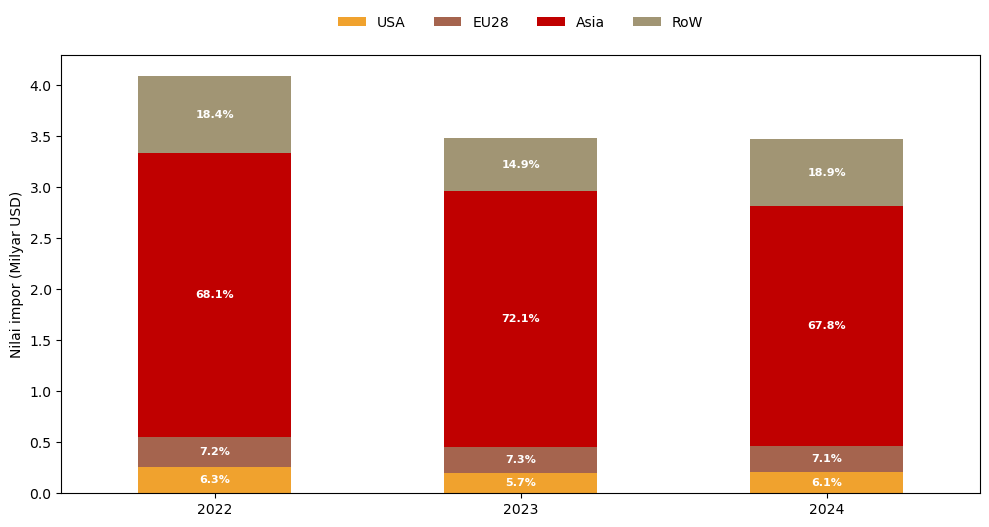

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- Step 1: Load dataset ---
df = pd.read_excel("../dat/padat karya ekspor to world.xlsx",sheet_name="fin2")

# ensure numeric year columns (coerce non-numeric to NaN)
year_cols = [2023, 2024, 2025]
#df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")

# --- Step 2: Aggregate by Region ---
region_summary = df.groupby("Region")[year_cols].sum()

# --- Step 3: Transpose for plotting ---
region_summary = region_summary.T
region_summary = region_summary[["USA","EU28","Asia","RoW"]]  # enforce order

# --- Step 4: Plot stacked bar chart with custom colors ---
colors = ["#f0a22e","#a5644e","#c00000","#a19574"]
ax = region_summary.plot(kind="bar", stacked=True, figsize=(10,6), color=colors)

# --- Step 5: Annotate percentage shares ---
for i, year in enumerate(region_summary.index):
    total = region_summary.loc[year].sum()
    cumulative = 0
    for region, value in region_summary.loc[year].items():
        cumulative += value
        pct = value / total * 100
        ax.text(
            i, cumulative - value/2, f"{pct:.1f}%", 
            ha="center", va="center", color="white", fontsize=8, fontweight="bold"
        )

# --- Step 6: Customize chart ---
ax.legend(title=None, bbox_to_anchor=(0.5, 1.12), loc="upper center", ncol=4, frameon=False)
formatter = FuncFormatter(lambda x, pos: f"{x/1e6:.1f}")
ax.yaxis.set_major_formatter(formatter)
plt.xticks(rotation=0)
plt.xlabel("")
plt.ylabel("Nilai impor (Milyar USD)")

# Set x-axis to show years as integers
ax.set_xticklabels([int(x) for x in region_summary.index])

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("../fig/fig2.png", dpi=300)
plt.show()


## Ekspor impor by HS Indonesia

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

colors = ["#f0a22e","#a5644e"]
# --- Step 1: Load dataset (preview of the trade-by-type data) ---
df = pd.read_excel("Ekspor Impor Indo Padat Karya.xlsx", sheet_name="fin")
df

Figure saved to: trade_by_type.png


Figure saved to: trade_by_type_id.png


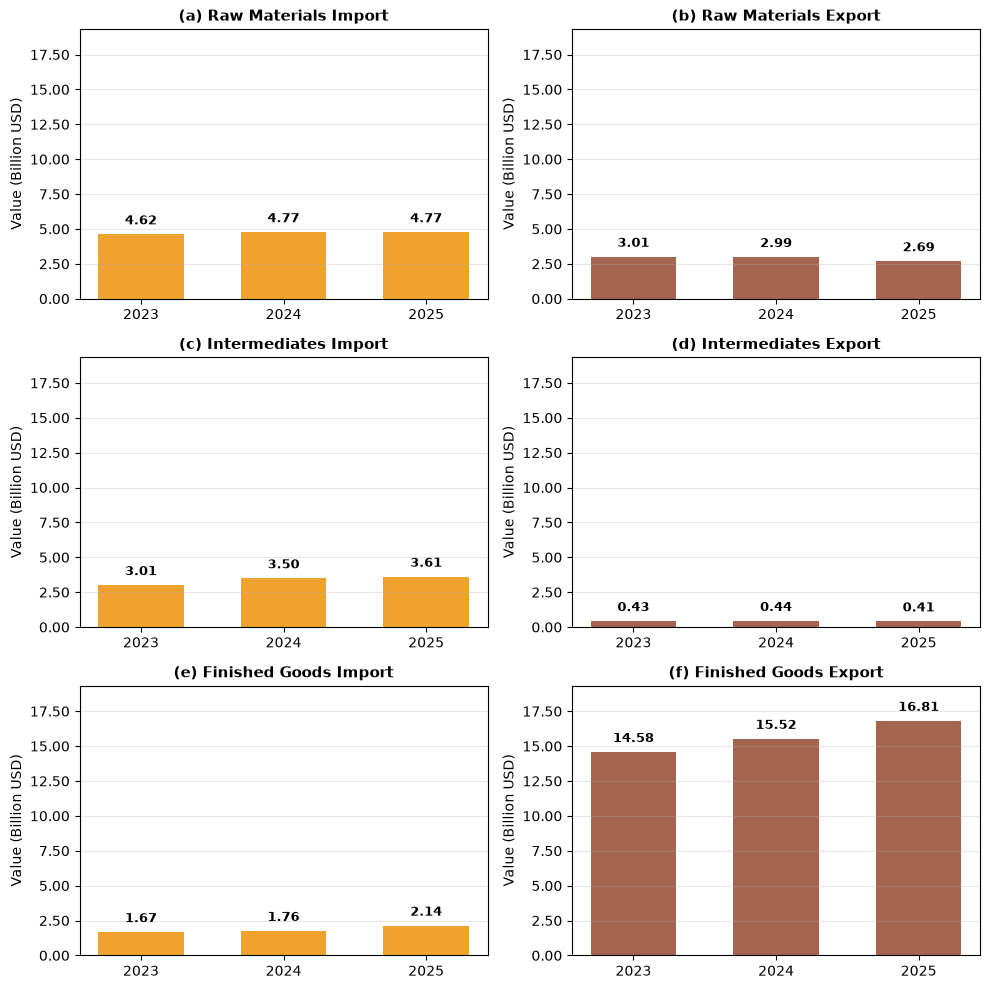

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from source_note import save_with_source

excel_path = "Ekspor Impor Indo Padat Karya.xlsx"
fig_path   = "trade_by_type.png"

colors = ["#f0a22e", "#a5644e"]

# --- Step 1: Load dataset ---
df = pd.read_excel(excel_path, sheet_name="fin")

# --- Step 2: Sum Value by Tahun, Flow, and type ---
df_agg = df.groupby(['Tahun', 'Flow', 'type'])['Value'].sum().reset_index()
df_agg['Value_Billion'] = df_agg['Value'] / 1e9

# --- Step 3: Prepare data for plotting ---
years = sorted(df_agg['Tahun'].unique())

types_order = ['raw materials', 'intermediates', 'Finished']
types_eng   = {'raw materials': 'Raw Materials', 'intermediates': 'Intermediates', 'Finished': 'Finished Goods'}
flows       = ['Import', 'Export']
flow_eng    = {'Import': 'Import', 'Export': 'Export'}

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

max_val = df_agg['Value_Billion'].max() * 1.15

def format_eng(val):
    return f"{val:,.2f}"   # standard English format: 1,234.56

for row_idx, type_name in enumerate(types_order):
    for col_idx, flow in enumerate(flows):
        ax = axes[row_idx, col_idx]
        label_idx = row_idx * 2 + col_idx

        data = df_agg[(df_agg['type'] == type_name) & (df_agg['Flow'] == flow)]

        values = []
        for year in years:
            val = data[data['Tahun'] == year]['Value_Billion'].values
            values.append(val[0] if len(val) > 0 else 0)

        bar_color = colors[0] if flow == 'Import' else colors[1]
        bars = ax.bar([str(y) for y in years], values, color=bar_color, width=0.6)

        for bar, val in zip(bars, values):
            ax.annotate(format_eng(val),
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 5),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

        title = f"{labels[label_idx]} {types_eng[type_name]} {flow_eng[flow]}"
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylim(0, max_val)
        ax.set_ylabel('Value (Billion USD)', fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format_eng(x)))
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_with_source(fig, fig_path, "UN COMTRADE.")
plt.show()

## Smile Curve

Figure saved to: smile_curve_indonesia.png


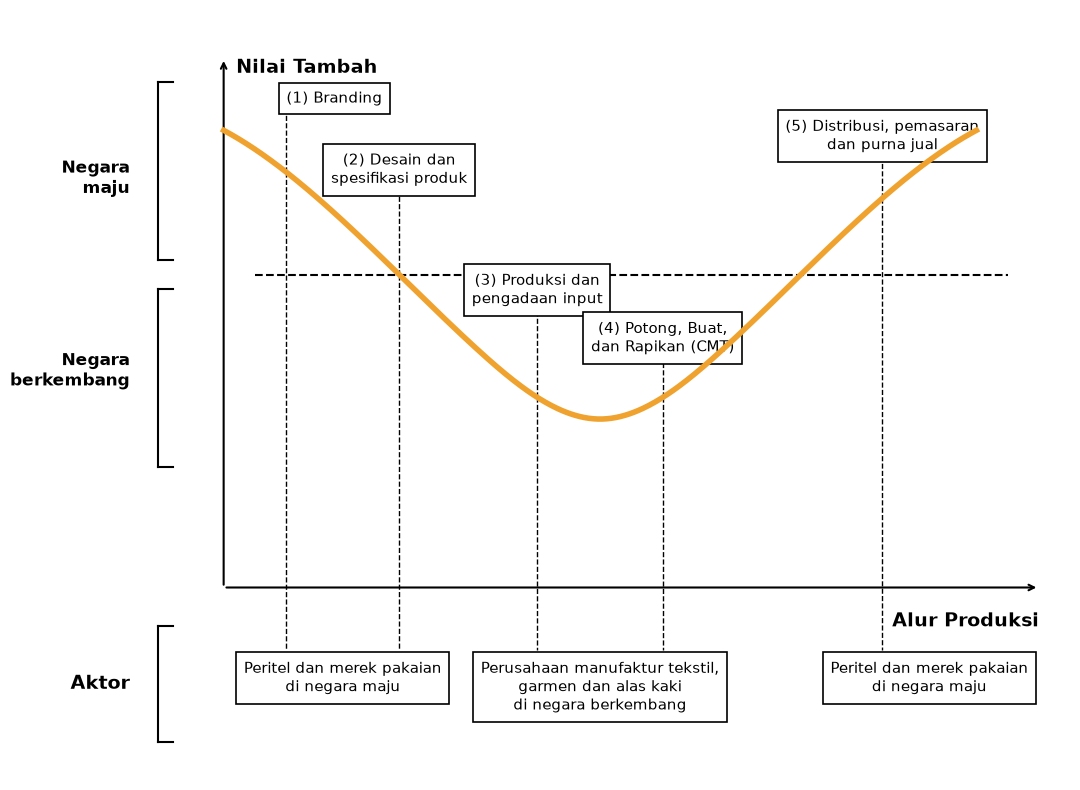

In [7]:
import matplotlib.pyplot as plt
from source_note import save_with_note
import matplotlib.patches as patches
import numpy as np
from scipy.interpolate import make_interp_spline

# --- Konfigurasi Data untuk Kurva ---
# Titik kunci untuk kurva senyum dengan slope yang lebih konsisten
x_points = np.array([0, 2, 4, 6, 8, 10, 12])
y_points = np.array([9.5, 7.5, 5, 3.5, 5, 7.5, 9.5])  # Lebih simetris

# Menggunakan spline untuk menghaluskan kurva
X_Y_Spline = make_interp_spline(x_points, y_points)
X_smooth = np.linspace(x_points.min(), x_points.max(), 500)
Y_smooth = X_Y_Spline(X_smooth)

# --- Setup Plot (lebih compact) ---
fig, ax = plt.subplots(figsize=(11, 8))

# Warna oranye untuk kurva
curve_color = '#f0a22e'

# Plot garis kurva
ax.plot(X_smooth, Y_smooth, color=curve_color, linewidth=4, zorder=5)

# --- Kustomisasi Sumbu (Axes) ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Sumbu Y (Nilai Tambah)
baseline_y = 0
ax.annotate("", xy=(0, 11), xytext=(0, baseline_y),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax.text(0.2, 10.8, "Nilai Tambah", fontsize=14, ha='left', va='center', fontweight='bold')

# Sumbu X (Alur Produksi)
ax.annotate("", xy=(13, baseline_y), xytext=(0, baseline_y),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax.text(13, baseline_y - 0.5, "Alur Produksi", fontsize=14, ha='right', va='top', fontweight='bold')

# --- Posisi X untuk setiap tahapan ---
x_stage1 = 1      # Branding
x_stage2 = 2.8    # Desain
x_stage3 = 5      # Produksi input
x_stage4 = 7      # CMT
x_stage5 = 10.5   # Distribusi

# Nilai Y kurva pada setiap posisi X
y_curve_1 = np.interp(x_stage1, X_smooth, Y_smooth)
y_curve_2 = np.interp(x_stage2, X_smooth, Y_smooth)
y_curve_3 = np.interp(x_stage3, X_smooth, Y_smooth)
y_curve_4 = np.interp(x_stage4, X_smooth, Y_smooth)
y_curve_5 = np.interp(x_stage5, X_smooth, Y_smooth)

# --- Garis horizontal putus-putus pemisah negara maju dan berkembang ---
y_separator = 6.5  # Posisi Y garis pemisah
ax.plot([0.5, 12.5], [y_separator, y_separator], 'k--', lw=1.5, zorder=2)

# --- Label "Negara Maju" dengan kurung siku (di atas garis pemisah) ---
ax.text(-1.5, 8.5, "Negara\nmaju", fontsize=12, ha='right', va='center', fontweight='bold')
# Kurung siku untuk negara maju
bracket_nm_x = -0.8
ax.plot([bracket_nm_x, bracket_nm_x - 0.25], [y_separator + 0.3, y_separator + 0.3], 'k-', lw=1.5)
ax.plot([bracket_nm_x - 0.25, bracket_nm_x - 0.25], [y_separator + 0.3, 10.5], 'k-', lw=1.5)
ax.plot([bracket_nm_x, bracket_nm_x - 0.25], [10.5, 10.5], 'k-', lw=1.5)

# --- Label "Negara Berkembang" dengan kurung siku (di bawah garis pemisah) ---
ax.text(-1.5, 4.5, "Negara\nberkembang", fontsize=12, ha='right', va='center', fontweight='bold')
# Kurung siku untuk negara berkembang
ax.plot([bracket_nm_x, bracket_nm_x - 0.25], [y_separator - 0.3, y_separator - 0.3], 'k-', lw=1.5)
ax.plot([bracket_nm_x - 0.25, bracket_nm_x - 0.25], [y_separator - 0.3, 2.5], 'k-', lw=1.5)
ax.plot([bracket_nm_x, bracket_nm_x - 0.25], [2.5, 2.5], 'k-', lw=1.5)

# --- Fungsi untuk menggambar kotak tahapan ---
def draw_stage_box(x_pos, y_curve, box_y, text, ax_ref, ha='center'):
    # Garis putus-putus dari kurva ke kotak
    ax_ref.plot([x_pos, x_pos], [y_curve, box_y + 0.2], 
                color='black', linestyle='--', linewidth=1, zorder=1)
    # Kotak teks (font lebih besar)
    bbox_props = dict(boxstyle="square,pad=0.5", fc="white", ec="black", lw=1.2)
    ax_ref.text(x_pos, box_y, text, ha=ha, va='bottom', fontsize=11, bbox=bbox_props)

# --- Tahapan (Kotak Atas) - posisi disesuaikan agar tidak menabrak garis ---
draw_stage_box(x_stage1, y_curve_1, 10, "(1) Branding", ax, ha='left')
draw_stage_box(x_stage2, y_curve_2, 8.3, "(2) Desain dan\nspesifikasi produk", ax)
draw_stage_box(x_stage3, y_curve_3, 5.8, "(3) Produksi dan\npengadaan input", ax)
draw_stage_box(x_stage4, y_curve_4, 4.8, "(4) Potong, Buat,\ndan Rapikan (CMT)", ax)
draw_stage_box(x_stage5, y_curve_5, 9, "(5) Distribusi, pemasaran\ndan purna jual", ax)

# --- Garis putus-putus vertikal menembus sumbu X ke bawah ---
ax.plot([x_stage1, x_stage1], [y_curve_1, -1.3], 'k--', lw=1, zorder=1)
ax.plot([x_stage2, x_stage2], [y_curve_2, -1.3], 'k--', lw=1, zorder=1)
ax.plot([x_stage3, x_stage3], [y_curve_3, -1.3], 'k--', lw=1, zorder=1)
ax.plot([x_stage4, x_stage4], [y_curve_4, -1.3], 'k--', lw=1, zorder=1)
ax.plot([x_stage5, x_stage5], [y_curve_5, -1.3], 'k--', lw=1, zorder=1)

# --- Aktor (Kotak Bawah) - 3 kotak dalam 1 baris ---
def draw_actor_box(x_center, y_pos, text, ax_ref):
    bbox_props = dict(boxstyle="square,pad=0.5", fc="white", ec="black", lw=1.2)
    ax_ref.text(x_center, y_pos, text, ha='center', va='top', fontsize=11, bbox=bbox_props)

# Label "Aktor" dengan kurung siku di kiri
ax.text(-1.5, -2, "Aktor", fontsize=14, ha='right', va='center', fontweight='bold')

# Kurung siku untuk Aktor
bracket_x = -0.8
ax.plot([bracket_x, bracket_x - 0.25], [-0.8, -0.8], 'k-', lw=1.5)
ax.plot([bracket_x - 0.25, bracket_x - 0.25], [-0.8, -3.2], 'k-', lw=1.5)
ax.plot([bracket_x, bracket_x - 0.25], [-3.2, -3.2], 'k-', lw=1.5)

# Aktor 1: Peritel di negara maju (kiri, untuk Branding & Desain)
draw_actor_box(1.9, -1.5, "Peritel dan merek pakaian\ndi negara maju", ax)

# Aktor 2: Perusahaan manufaktur (tengah, untuk Produksi input & CMT)
draw_actor_box(6, -1.5, "Perusahaan manufaktur tekstil,\ngarmen dan alas kaki\ndi negara berkembang", ax)

# Aktor 3: Peritel di negara maju (kanan, untuk Distribusi)
draw_actor_box(11.25, -1.5, "Peritel dan merek pakaian\ndi negara maju", ax)

# --- Atur batas canvas ---
ax.set_xlim(-2.5, 13.5)
ax.set_ylim(-4, 12)
plt.tight_layout()

# Simpan atau tampilkan
save_with_note(fig, "smile_curve_indonesia.png", "Sumber: Goto (2023), perhitungan penulis.")
plt.show()

Figure saved to: smile_curve_english.png


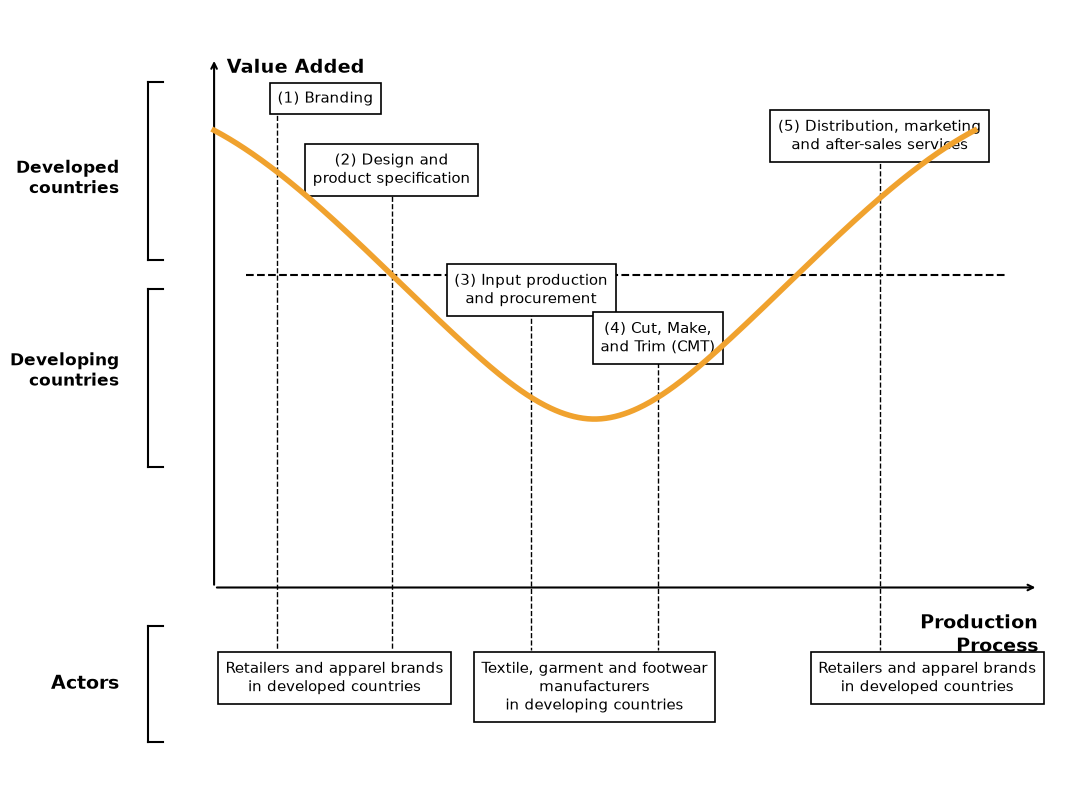

In [8]:
import matplotlib.pyplot as plt
from source_note import save_with_note
import matplotlib.patches as patches
import numpy as np
from scipy.interpolate import make_interp_spline

# --- English version of the smile curve (used in the English paper) ---
# Key points for a smile curve with more consistent slopes
x_points = np.array([0, 2, 4, 6, 8, 10, 12])
y_points = np.array([9.5, 7.5, 5, 3.5, 5, 7.5, 9.5])  # more symmetric

# Smooth the curve with a spline
X_Y_Spline = make_interp_spline(x_points, y_points)
X_smooth = np.linspace(x_points.min(), x_points.max(), 500)
Y_smooth = X_Y_Spline(X_smooth)

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(11, 8))

curve_color = '#f0a22e'

ax.plot(X_smooth, Y_smooth, color=curve_color, linewidth=4, zorder=5)

# --- Axis customization ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Y axis (Value Added)
baseline_y = 0
ax.annotate("", xy=(0, 11), xytext=(0, baseline_y),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax.text(0.2, 10.8, "Value Added", fontsize=14, ha='left', va='center', fontweight='bold')

# X axis (Production Process)
ax.annotate("", xy=(13, baseline_y), xytext=(0, baseline_y),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax.text(13, baseline_y - 0.5, "Production\nProcess", fontsize=14, ha='right', va='top', fontweight='bold')

# --- X position of each stage ---
x_stage1 = 1      # Branding
x_stage2 = 2.8    # Design
x_stage3 = 5      # Input production
x_stage4 = 7      # CMT
x_stage5 = 10.5   # Distribution

# Curve y values at each stage position
y_curve_1 = np.interp(x_stage1, X_smooth, Y_smooth)
y_curve_2 = np.interp(x_stage2, X_smooth, Y_smooth)
y_curve_3 = np.interp(x_stage3, X_smooth, Y_smooth)
y_curve_4 = np.interp(x_stage4, X_smooth, Y_smooth)
y_curve_5 = np.interp(x_stage5, X_smooth, Y_smooth)

# --- Dashed horizontal separator between developed and developing countries ---
y_separator = 6.5
ax.plot([0.5, 12.5], [y_separator, y_separator], 'k--', lw=1.5, zorder=2)

# --- "Developed countries" label with bracket (above the separator) ---
ax.text(-1.5, 8.5, "Developed\ncountries", fontsize=12, ha='right', va='center', fontweight='bold')
bracket_nm_x = -0.8
ax.plot([bracket_nm_x, bracket_nm_x - 0.25], [y_separator + 0.3, y_separator + 0.3], 'k-', lw=1.5)
ax.plot([bracket_nm_x - 0.25, bracket_nm_x - 0.25], [y_separator + 0.3, 10.5], 'k-', lw=1.5)
ax.plot([bracket_nm_x, bracket_nm_x - 0.25], [10.5, 10.5], 'k-', lw=1.5)

# --- "Developing countries" label with bracket (below the separator) ---
ax.text(-1.5, 4.5, "Developing\ncountries", fontsize=12, ha='right', va='center', fontweight='bold')
ax.plot([bracket_nm_x, bracket_nm_x - 0.25], [y_separator - 0.3, y_separator - 0.3], 'k-', lw=1.5)
ax.plot([bracket_nm_x - 0.25, bracket_nm_x - 0.25], [y_separator - 0.3, 2.5], 'k-', lw=1.5)
ax.plot([bracket_nm_x, bracket_nm_x - 0.25], [2.5, 2.5], 'k-', lw=1.5)

# --- Helper to draw stage boxes ---
def draw_stage_box(x_pos, y_curve, box_y, text, ax_ref, ha='center'):
    # Dashed line from curve to box
    ax_ref.plot([x_pos, x_pos], [y_curve, box_y + 0.2],
                color='black', linestyle='--', linewidth=1, zorder=1)
    bbox_props = dict(boxstyle="square,pad=0.5", fc="white", ec="black", lw=1.2)
    ax_ref.text(x_pos, box_y, text, ha=ha, va='bottom', fontsize=11, bbox=bbox_props)

# --- Stages (upper boxes) ---
draw_stage_box(x_stage1, y_curve_1, 10, "(1) Branding", ax, ha='left')
draw_stage_box(x_stage2, y_curve_2, 8.3, "(2) Design and\nproduct specification", ax)
draw_stage_box(x_stage3, y_curve_3, 5.8, "(3) Input production\nand procurement", ax)
draw_stage_box(x_stage4, y_curve_4, 4.8, "(4) Cut, Make,\nand Trim (CMT)", ax)
draw_stage_box(x_stage5, y_curve_5, 9, "(5) Distribution, marketing\nand after-sales services", ax)

# --- Dashed vertical lines extending below the x axis ---
ax.plot([x_stage1, x_stage1], [y_curve_1, -1.3], 'k--', lw=1, zorder=1)
ax.plot([x_stage2, x_stage2], [y_curve_2, -1.3], 'k--', lw=1, zorder=1)
ax.plot([x_stage3, x_stage3], [y_curve_3, -1.3], 'k--', lw=1, zorder=1)
ax.plot([x_stage4, x_stage4], [y_curve_4, -1.3], 'k--', lw=1, zorder=1)
ax.plot([x_stage5, x_stage5], [y_curve_5, -1.3], 'k--', lw=1, zorder=1)

# --- Actors (lower boxes) ---
def draw_actor_box(x_center, y_pos, text, ax_ref):
    bbox_props = dict(boxstyle="square,pad=0.5", fc="white", ec="black", lw=1.2)
    ax_ref.text(x_center, y_pos, text, ha='center', va='top', fontsize=11, bbox=bbox_props)

# "Actors" label with bracket on the left
ax.text(-1.5, -2, "Actors", fontsize=14, ha='right', va='center', fontweight='bold')

bracket_x = -0.8
ax.plot([bracket_x, bracket_x - 0.25], [-0.8, -0.8], 'k-', lw=1.5)
ax.plot([bracket_x - 0.25, bracket_x - 0.25], [-0.8, -3.2], 'k-', lw=1.5)
ax.plot([bracket_x, bracket_x - 0.25], [-3.2, -3.2], 'k-', lw=1.5)

# Actor 1: retailers/brands in developed countries (left: branding & design)
draw_actor_box(1.9, -1.5, "Retailers and apparel brands\nin developed countries", ax)

# Actor 2: manufacturers (middle: input production & CMT)
draw_actor_box(6, -1.5, "Textile, garment and footwear\nmanufacturers\nin developing countries", ax)

# Actor 3: retailers/brands in developed countries (right: distribution)
draw_actor_box(11.25, -1.5, "Retailers and apparel brands\nin developed countries", ax)

# --- Canvas limits ---
ax.set_xlim(-2.5, 13.5)
ax.set_ylim(-4, 12)
plt.tight_layout()

save_with_note(fig, "smile_curve_english.png", "Source: Goto (2023), author's calculation.")
plt.show()